# UrbanInsight — YOLOv8-Seg + SegFormer Pipeline
### Optimized for Tesla T4 (16GB) | Instance Building Detection + Land Use
---
**Architecture:**
- **YOLOv8l-seg** → Building instance segmentation (FR-2, FR-3)
  - Bounding boxes + pixel masks + unique IDs + confidence
  - Handles touching/overlapping buildings
- **SegFormer-B2** → Land use classification (FR-4)
  - Built-up / Vegetation / Open Land / Road / Water

**Why this works better than SAM+CLIP or pure SegFormer:**
- YOLOv8 does detection + segmentation in ONE forward pass
- Each building is a separate instance (no watershed needed)
- SegFormer handles the semantic land-use classification
- Both fit easily on T4 with FP16


In [2]:
import os, platform, torch

print("Python:", platform.python_version())
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Memory: {mem:.1f} GB")

device = "cuda" if torch.cuda.is_available() else "cpu"

# Project structure
BASE = "/content/urban_project"
DATA = os.path.join(BASE, "data")
WORK = os.path.join(BASE, "work")
CKPT = os.path.join(BASE, "checkpoints")
OUT  = os.path.join(BASE, "output")
for d in [DATA, WORK, CKPT, OUT]:
    os.makedirs(d, exist_ok=True)
print(f"\nDevice: {device.upper()}")


Python: 3.12.13
CUDA: True
GPU: Tesla T4
GPU Memory: 15.6 GB

Device: CUDA


In [3]:
# ================================================================
# INSTALL — Run once, then Restart Runtime
# ================================================================

!pip install -q ultralytics  # YOLOv8
!pip install -q transformers accelerate safetensors
!pip install -q shapely rasterio geopandas
!pip install -q boto3

import numpy as np; print(f"numpy {np.__version__}")
import cv2; print(f"opencv {cv2.__version__}")
import torch; print(f"torch {torch.__version__}")

print("\n" + "=" * 50)
print("DONE! Now: Runtime -> Restart runtime")
print("Then run from the NEXT cell onward")
print("=" * 50)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.7 MB/s eta 0:00:00
numpy 2.0.2
opencv 4.13.0
torch 2.10.0+cu128

DONE! Now: Runtime -> Restart runtime
Then run from the NEXT cell onward


In [4]:
import os, json, math, time, glob, random, uuid, warnings
from typing import List, Dict, Tuple
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from ultralytics import YOLO

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
    get_cosine_schedule_with_warmup,
)

import rasterio
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape as shapely_shape

warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
BASE = "/content/urban_project"
DATA = os.path.join(BASE, "data")
WORK = os.path.join(BASE, "work")
CKPT = os.path.join(BASE, "checkpoints")
OUT  = os.path.join(BASE, "output")
for d in [DATA, WORK, CKPT, OUT]:
    os.makedirs(d, exist_ok=True)

print("All imports ready!")
print(f"Device: {device.upper()}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports ready!
Device: CUDA


In [8]:
!rm -rf /content/urban_project/data/spacenet/AOI_2_Vegas/

In [9]:
# ================================================================
# ★★★ FIX: DOWNLOAD FROM CORRECT SPACENET PATH ★★★
# ================================================================
# PROBLEM: AOIs/AOI_2_Vegas/ has RAW mosaic imagery WITHOUT labels
# SOLUTION: spacenet/SN2_buildings/train/AOI_2_Vegas/ has
#           3850 pre-cut 650x650 tiles WITH building GeoJSON labels
# ================================================================

import os, glob, shutil
import boto3
from botocore import UNSIGNED
from botocore.config import Config

# --- Clean old data first ---
print("=" * 60)
print("STEP 1: Cleaning old downloads...")
print("=" * 60)

old_data = os.path.join(DATA, "spacenet", "AOI_2_Vegas")
if os.path.exists(old_data):
    size_before = sum(os.path.getsize(os.path.join(dp, f))
                      for dp, dn, fnames in os.walk(old_data)
                      for f in fnames) / 1e9
    shutil.rmtree(old_data, ignore_errors=True)
    print(f"  Removed old data: {size_before:.1f} GB freed")

# Also clean caches
for p in ["/root/.cache/pip", "/tmp/pip-*"]:
    if os.path.exists(p):
        shutil.rmtree(p, ignore_errors=True)

disk = shutil.disk_usage("/")
print(f"  Disk: {disk.free/1e9:.1f} GB free / {disk.total/1e9:.1f} GB total")

# --- Download from CORRECT path ---
print("\n" + "=" * 60)
print("STEP 2: Downloading from spacenet/SN2_buildings/train/AOI_2_Vegas/")
print("=" * 60)

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
bucket = "spacenet-dataset"

# The CORRECT prefix with pre-cut tiles + labels
SN2_PREFIX = "spacenet/SN2_buildings/train/AOI_2_Vegas/"

print(f"Scanning s3://{bucket}/{SN2_PREFIX} ...")

all_keys = []
paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=bucket, Prefix=SN2_PREFIX):
    for obj in page.get("Contents", []):
        all_keys.append((obj["Key"], obj["Size"]))

print(f"Total files: {len(all_keys)}")

# Categorize
categories = {}
for key, size in all_keys:
    parts = key.replace(SN2_PREFIX, "").split("/")
    cat = parts[0] if parts else "root"
    if cat not in categories:
        categories[cat] = {"count": 0, "size": 0, "samples": []}
    categories[cat]["count"] += 1
    categories[cat]["size"] += size
    if len(categories[cat]["samples"]) < 3:
        categories[cat]["samples"].append(key)

print("\nAvailable folders:")
for cat, info in sorted(categories.items(), key=lambda x: -x[1]["size"]):
    print(f"  {info['size']/1e6:8.1f} MB  ({info['count']:4d} files)  {cat}/")
    for s in info["samples"]:
        print(f"    └ {os.path.basename(s)}")

# --- Select: PS-RGB images + geojson_buildings labels ---
img_keys = [k for k, s in all_keys
            if "/PS-RGB/" in k and k.lower().endswith(".tif")]
label_keys = [k for k, s in all_keys
              if "/geojson_buildings/" in k and k.lower().endswith(".geojson")]

# If no PS-RGB, try PS-MS
if not img_keys:
    img_keys = [k for k, s in all_keys
                if "/PS-MS/" in k and k.lower().endswith(".tif")]
    print("  Using PS-MS (no PS-RGB found)")

print(f"\n  PS-RGB images: {len(img_keys)}")
print(f"  Building labels: {len(label_keys)}")

# --- Limit download to save disk ---
# 3850 tiles × ~0.5MB = ~2GB for PS-RGB + labels
# If disk is tight, limit to fewer tiles
MAX_TILES = min(len(img_keys), 800)  # 800 tiles ≈ 400MB, plenty for training

disk = shutil.disk_usage("/")
free_gb = disk.free / 1e9
if free_gb < 20:
    MAX_TILES = min(MAX_TILES, 300)
    print(f"  ⚠️  Disk tight ({free_gb:.0f}GB free) — limiting to {MAX_TILES} tiles")
elif free_gb < 40:
    MAX_TILES = min(MAX_TILES, 500)

# Match images to labels by index number
import re

def get_img_index(key):
    """Extract imgNNN from filename."""
    m = re.search(r'img(\d+)', os.path.basename(key))
    return m.group(1) if m else None

# Build index → key mapping
img_by_idx = {get_img_index(k): k for k in img_keys if get_img_index(k)}
lbl_by_idx = {get_img_index(k): k for k in label_keys if get_img_index(k)}

# Find matched pairs (image + label exist)
matched_indices = sorted(set(img_by_idx.keys()) & set(lbl_by_idx.keys()))
print(f"  Matched image+label pairs: {len(matched_indices)}")

# Take first MAX_TILES matched pairs
selected_indices = matched_indices[:MAX_TILES]
selected_imgs = [img_by_idx[i] for i in selected_indices]
selected_lbls = [lbl_by_idx[i] for i in selected_indices]

total_size = sum(s for k, s in all_keys if k in selected_imgs + selected_lbls)
print(f"  Will download: {len(selected_indices)} pairs (~{total_size/1e6:.0f} MB)")

# --- Download ---
print("\n" + "=" * 60)
print("STEP 3: Downloading images + labels...")
print("=" * 60)

AOI_LOCAL = os.path.join(DATA, "spacenet", "SN2_Vegas")
os.makedirs(AOI_LOCAL, exist_ok=True)

to_download = selected_imgs + selected_lbls
count = 0

for key in to_download:
    # Keep folder structure: PS-RGB/file.tif or geojson_buildings/file.geojson
    rel_path = key.replace(SN2_PREFIX, "")
    local_path = os.path.join(AOI_LOCAL, rel_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)

    if not os.path.exists(local_path):
        try:
            s3.download_file(bucket, key, local_path)
            count += 1
            if count % 50 == 0:
                print(f"  {count}/{len(to_download)}...")
        except OSError as e:
            if "No space" in str(e):
                print(f"  ❌ DISK FULL! Downloaded {count} files before stopping.")
                break
            print(f"  Skip: {os.path.basename(key)} — {e}")

print(f"\nDownloaded: {count} new files")

# --- Verify ---
print("\n" + "=" * 60)
print("STEP 4: Verifying...")
print("=" * 60)

local_imgs = sorted(glob.glob(os.path.join(AOI_LOCAL, "PS-RGB", "*.tif")) +
                     glob.glob(os.path.join(AOI_LOCAL, "PS-MS", "*.tif")))
local_lbls = sorted(glob.glob(os.path.join(AOI_LOCAL, "geojson_buildings", "*.geojson")))

print(f"Local images: {len(local_imgs)}")
print(f"Local labels: {len(local_lbls)}")

if local_imgs:
    print(f"\nSample image: {os.path.basename(local_imgs[0])}")
    print(f"  Size: {os.path.getsize(local_imgs[0])/1e6:.1f} MB")
if local_lbls:
    print(f"Sample label: {os.path.basename(local_lbls[0])}")

# Set paths for next cells
IMG_TIF = local_imgs[0] if local_imgs else ""
BLD_GEOJSON = local_lbls[0] if local_lbls else ""

# Read first label to verify
if BLD_GEOJSON:
    test_gdf = gpd.read_file(BLD_GEOJSON)
    print(f"\n✓ Label file has {len(test_gdf)} buildings")
    print(f"  Columns: {list(test_gdf.columns)}")
    if hasattr(test_gdf, 'geometry') and test_gdf.geometry is not None:
        print(f"  CRS: {test_gdf.crs}")

disk = shutil.disk_usage("/")
print(f"\nDisk: {disk.free/1e9:.1f} GB free / {disk.total/1e9:.1f} GB total")
print(f"\n✓ IMG_TIF = {IMG_TIF}")
print(f"✓ BLD_GEOJSON = {BLD_GEOJSON}")

STEP 1: Cleaning old downloads...
  Disk: 74.8 GB free / 120.9 GB total

STEP 2: Downloading from spacenet/SN2_buildings/train/AOI_2_Vegas/
Scanning s3://spacenet-dataset/spacenet/SN2_buildings/train/AOI_2_Vegas/ ...
Total files: 19255

Available folders:
   26054.4 MB  (3851 files)  PS-MS/
    └ SN2_buildings_train_AOI_2_Vegas_PS-MS_img1.tif
    └ SN2_buildings_train_AOI_2_Vegas_PS-MS_img10.tif
    └ SN2_buildings_train_AOI_2_Vegas_PS-MS_img1000.tif
    9771.3 MB  (3850 files)  PS-RGB/
    └ SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1.tif
    └ SN2_buildings_train_AOI_2_Vegas_PS-RGB_img10.tif
    └ SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1002.tif
    3258.9 MB  (3851 files)  PAN/
    └ SN2_buildings_train_AOI_2_Vegas_PAN_img1.tif
    └ SN2_buildings_train_AOI_2_Vegas_PAN_img10.tif
    └ SN2_buildings_train_AOI_2_Vegas_PAN_img1000.tif
    1640.4 MB  (3851 files)  MS/
    └ SN2_buildings_train_AOI_2_Vegas_MS_img1.tif
    └ SN2_buildings_train_AOI_2_Vegas_MS_img10.tif
    └ SN2_buildin

Images: 800
Labels: 800
Matched pairs: 800


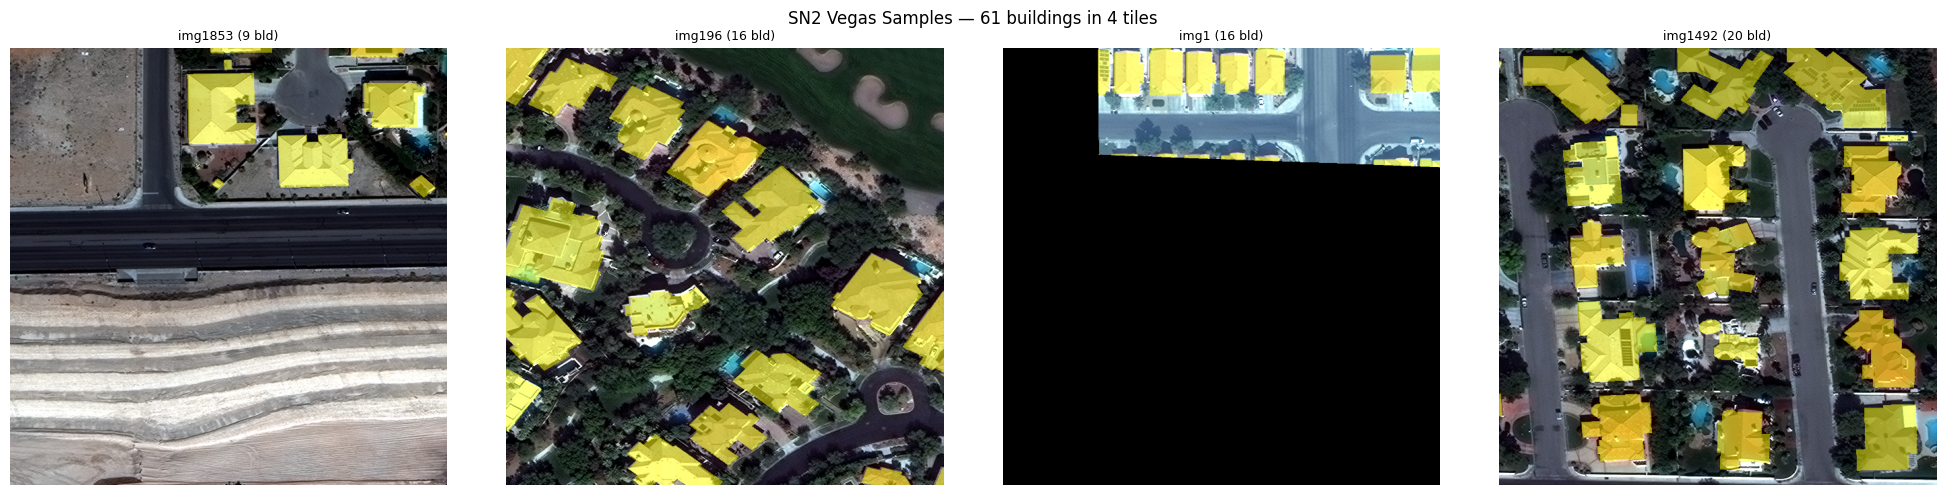


✓ Dataset ready: 800 image-label pairs
  Image size: 650x650 (SN2 pre-cut tiles)


In [10]:
# ================================================================
# ★★★ FIX CELL 6: READ SN2 PRE-CUT TILES (650x650)
# ================================================================
# SN2 structure: each image has its OWN geojson label file
#   PS-RGB/SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1.tif
#   geojson_buildings/SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1.geojson
# ================================================================

AOI_LOCAL = os.path.join(DATA, "spacenet", "SN2_Vegas")

# Find all image-label pairs
local_imgs = sorted(glob.glob(os.path.join(AOI_LOCAL, "PS-RGB", "*.tif")) +
                     glob.glob(os.path.join(AOI_LOCAL, "PS-MS", "*.tif")))
local_lbls = sorted(glob.glob(os.path.join(AOI_LOCAL, "geojson_buildings", "*.geojson")))

print(f"Images: {len(local_imgs)}")
print(f"Labels: {len(local_lbls)}")

import re

def get_img_num(path):
    m = re.search(r'img(\d+)', os.path.basename(path))
    return int(m.group(1)) if m else -1

# Match by image number
img_dict = {get_img_num(f): f for f in local_imgs}
lbl_dict = {get_img_num(f): f for f in local_lbls}

matched = sorted(set(img_dict.keys()) & set(lbl_dict.keys()))
print(f"Matched pairs: {len(matched)}")

# Read + rasterize helper
def read_tif_as_rgb(path):
    with rasterio.open(path) as src:
        img = src.read()
        n_bands = src.count
    if n_bands >= 3:
        rgb = img[:3].astype(np.float32).transpose(1, 2, 0)
    elif n_bands == 1:
        g = img[0].astype(np.float32)
        rgb = np.stack([g,g,g], axis=-1)
    else:
        rgb = img[:3].astype(np.float32).transpose(1, 2, 0)
    for c in range(3):
        lo, hi = np.percentile(rgb[:,:,c], [2, 98])
        rgb[:,:,c] = np.clip((rgb[:,:,c] - lo) / (hi - lo + 1e-9), 0, 1) * 255
    return np.clip(rgb, 0, 255).astype(np.uint8)

# Quick visual check — show 4 random pairs
sample_ids = random.sample(matched, min(4, len(matched)))
fig, axes = plt.subplots(1, len(sample_ids), figsize=(5*len(sample_ids), 5))
if len(sample_ids) == 1: axes = [axes]

total_buildings = 0
for ax, idx in zip(axes, sample_ids):
    img = read_tif_as_rgb(img_dict[idx])
    gdf = gpd.read_file(lbl_dict[idx])
    n_bld = len(gdf)
    total_buildings += n_bld

    # Rasterize
    with rasterio.open(img_dict[idx]) as src:
        tf = src.transform
        h, w = src.height, src.width
    if n_bld > 0:
        geoms = [(g, 1) for g in gdf.geometry if g is not None]
        mask = features.rasterize(geoms, out_shape=(h,w), transform=tf,
                                   fill=0, all_touched=True, dtype=np.uint8)
        ov = img.copy()
        ov[mask > 0] = (ov[mask > 0]*0.5 + np.array([255,255,0])*0.5).astype(np.uint8)
        ax.imshow(ov)
    else:
        ax.imshow(img)
    ax.set_title(f"img{idx} ({n_bld} bld)", fontsize=9)
    ax.axis("off")

plt.suptitle(f"SN2 Vegas Samples — {total_buildings} buildings in {len(sample_ids)} tiles", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✓ Dataset ready: {len(matched)} image-label pairs")
print(f"  Image size: 650x650 (SN2 pre-cut tiles)")



In [15]:
# ================================================================
# ★ CONVERT SN2 TILES → YOLO FORMAT (FIXED 3D coords)
# ================================================================

from rasterio.transform import rowcol
from shapely.geometry import Polygon

yolo_dir = os.path.join(WORK, "yolo_dataset")
for split in ["train", "val"]:
    os.makedirs(os.path.join(yolo_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(yolo_dir, "labels", split), exist_ok=True)

YOLO_SIZE = 640
MIN_POLY_AREA_PX = 30

all_samples = []
skipped = 0
debug_first = True  # print debug for first tile

for idx in tqdm(matched, desc="Converting to YOLO format"):
    img_path = img_dict[idx]
    lbl_path = lbl_dict[idx]

    try:
        img_rgb = read_tif_as_rgb(img_path)
    except:
        skipped += 1
        continue

    h, w = img_rgb.shape[:2]
    img_resized = cv2.resize(img_rgb, (YOLO_SIZE, YOLO_SIZE))

    gdf = gpd.read_file(lbl_path)

    with rasterio.open(img_path) as src:
        tf = src.transform

    # Debug first tile
    if debug_first and len(gdf) > 0:
        print(f"\n--- DEBUG img{idx} ---")
        print(f"  Image size: {w}x{h}")
        print(f"  Transform: {tf}")
        print(f"  GeoJSON features: {len(gdf)}")
        print(f"  Geom types: {gdf.geometry.geom_type.value_counts().to_dict()}")
        sample_geom = gdf.geometry.iloc[0]
        if sample_geom is not None:
            coords = list(sample_geom.exterior.coords) if hasattr(sample_geom, 'exterior') else []
            print(f"  Sample coord: {coords[0] if coords else 'N/A'}")
            print(f"  Coord dimensions: {len(coords[0]) if coords else 0}")
        debug_first = False

    labels = []
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue

        if geom.geom_type == 'Polygon':
            polys = [geom]
        elif geom.geom_type == 'MultiPolygon':
            polys = list(geom.geoms)
        else:
            continue

        for poly in polys:
            try:
                pixel_coords = []
                for coord in poly.exterior.coords:
                    x, y = coord[0], coord[1]  # ★ FIX: handle 3D (x,y,z)
                    pr, pc = rowcol(tf, x, y)
                    pixel_coords.append((pc, pr))

                sp = Polygon(pixel_coords)
                if sp.area < MIN_POLY_AREA_PX:
                    continue

                norm_coords = []
                for px, py in pixel_coords[:-1]:
                    nx = max(0.0, min(1.0, px / w))
                    ny = max(0.0, min(1.0, py / h))
                    norm_coords.extend([nx, ny])

                if len(norm_coords) >= 6:
                    label_str = "0 " + " ".join(f"{v:.6f}" for v in norm_coords)
                    labels.append(label_str)
            except:
                continue

    all_samples.append({
        "idx": idx,
        "img": img_resized,
        "labels": labels,
        "has_buildings": len(labels) > 0,
    })

print(f"\nProcessed: {len(all_samples)} tiles (skipped {skipped})")
tiles_with_bld = sum(1 for s in all_samples if s["has_buildings"])
print(f"Tiles with buildings: {tiles_with_bld}/{len(all_samples)}")
total_bld = sum(len(s["labels"]) for s in all_samples)
print(f"Total building instances: {total_bld}")

# Split 85/15
random.seed(42)
random.shuffle(all_samples)
split_idx = int(0.85 * len(all_samples))
train_samples = all_samples[:split_idx]
val_samples = all_samples[split_idx:]

for split_name, samples in [("train", train_samples), ("val", val_samples)]:
    for s in samples:
        name = f"SN2_Vegas_img{s['idx']:05d}"
        ip = os.path.join(yolo_dir, "images", split_name, f"{name}.png")
        Image.fromarray(s["img"]).save(ip)
        lp = os.path.join(yolo_dir, "labels", split_name, f"{name}.txt")
        with open(lp, "w") as f:
            f.write("\n".join(s["labels"]))

for s in all_samples:
    del s["img"]

print(f"\nTrain: {len(train_samples)} | Val: {len(val_samples)}")
non_empty = [f for f in glob.glob(os.path.join(yolo_dir, "labels", "train", "*.txt"))
             if os.path.getsize(f) > 0]
print(f"Non-empty labels (train): {len(non_empty)}")

Converting to YOLO format:   0%|          | 4/800 [00:00<00:44, 18.02it/s]


--- DEBUG img1 ---
  Image size: 650x650
  Transform: | 0.00, 0.00,-115.31|
| 0.00,-0.00, 36.13|
| 0.00, 0.00, 1.00|
  GeoJSON features: 16
  Geom types: {'Polygon': 15, 'Point': 1}
  Sample coord: (-115.30709085, 36.128288449000024, 0.0)
  Coord dimensions: 3


Converting to YOLO format: 100%|██████████| 800/800 [00:49<00:00, 16.12it/s]



Processed: 800 tiles (skipped 0)
Tiles with buildings: 767/800
Total building instances: 24591

Train: 680 | Val: 120
Non-empty labels (train): 652


In [17]:
# ★ CONVERT SPACENET → YOLO SEGMENTATION FORMAT
# ================================================================
# Improved: processes ALL downloaded TIF images, not just one
# ================================================================

TILE = 640
STRIDE = 480
MIN_POLY_AREA = 100

yolo_dir = os.path.join(WORK, "yolo_dataset")
for split in ["train", "val"]:
    os.makedirs(os.path.join(yolo_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(yolo_dir, "labels", split), exist_ok=True)

from rasterio.transform import rowcol
from shapely.geometry import Polygon, MultiPolygon, box as shapely_box

def geom_to_pixel_coords(geom, transform):
    if geom.is_empty:
        return None
    coords = []
    if geom.geom_type == 'Polygon':
        for coord in geom.exterior.coords:
            x, y = coord[0], coord[1]  # ignore Z if present
            row, col = rowcol(transform, x, y)
            coords.append((col, row))
        return [coords]
    elif geom.geom_type == 'MultiPolygon':
        result = []
        for poly in geom.geoms:
            poly_coords = []
            for coord in poly.exterior.coords:
                x, y = coord[0], coord[1]  # ignore Z if present
                row, col = rowcol(transform, x, y)
                poly_coords.append((col, row))
            result.append(poly_coords)
        return result
    return None


# Find ALL available TIF images (not just one)
all_tifs = sorted(glob.glob(os.path.join(AOI_LOCAL, "**", "*.[Tt][Ii][Ff]"), recursive=True) +
                  glob.glob(os.path.join(AOI_LOCAL, "**", "*.[Tt][Ii][Ff][Ff]"), recursive=True))

# Filter to the same type as IMG_TIF
img_type_folder = os.path.basename(os.path.dirname(IMG_TIF)).lower()
same_type_tifs = [f for f in all_tifs if img_type_folder in f.lower()]
if not same_type_tifs:
    same_type_tifs = [IMG_TIF]

print(f"Processing {len(same_type_tifs)} TIF images of type '{img_type_folder}'")

all_tiles = []
total_buildings_found = 0

for tif_idx, tif_path in enumerate(same_type_tifs):
    tif_name = os.path.basename(tif_path).split(".")[0]
    print(f"\n[{tif_idx+1}/{len(same_type_tifs)}] {tif_name}...")

    # Read image
    try:
        img_rgb = read_tif_as_rgb(tif_path)
    except Exception as e:
        print(f"  Skip (read error): {e}")
        continue

    # Get transform for this image
    with rasterio.open(tif_path) as src:
        tif_transform = src.transform
        tif_h, tif_w = src.height, src.width
        tif_crs = src.crs

    # Reproject labels if needed
    gdf_local = gdf.copy()
    if gdf_local.crs and tif_crs and gdf_local.crs != tif_crs:
        gdf_local = gdf_local.to_crs(tif_crs)

    # Convert polygons to pixel coordinates for THIS image
    pixel_polys = []
    for idx, row in gdf_local.iterrows():
        if row.geometry is None or row.geometry.is_empty:
            continue
        pc = geom_to_pixel_coords(row.geometry, tif_transform)
        if pc:
            for coords in pc:
                try:
                    poly = Polygon(coords)
                    if poly.is_valid and poly.area >= MIN_POLY_AREA:
                        # Check if polygon is within image bounds
                        bounds = poly.bounds
                        if (bounds[0] >= -TILE and bounds[1] >= -TILE and
                            bounds[2] <= tif_w + TILE and bounds[3] <= tif_h + TILE):
                            pixel_polys.append(poly)
                except:
                    pass

    print(f"  Image: {tif_w}x{tif_h} | Valid polygons in view: {len(pixel_polys)}")
    total_buildings_found += len(pixel_polys)

    if len(pixel_polys) == 0:
        print(f"  ⚠️  No buildings in this tile — skipping")
        continue

    # Tile this image
    H, W = img_rgb.shape[:2]
    tile_count_this = 0

    for y in range(0, H - TILE + 1, STRIDE):
        for x in range(0, W - TILE + 1, STRIDE):
            tile_img = img_rgb[y:y+TILE, x:x+TILE]
            if tile_img.mean() < 5:
                continue

            tile_box = shapely_box(x, y, x + TILE, y + TILE)

            labels = []
            for poly in pixel_polys:
                if not poly.intersects(tile_box):
                    continue
                try:
                    clipped = poly.intersection(tile_box)
                except:
                    continue
                if clipped.is_empty or clipped.area < 50:
                    continue

                polys_to_process = []
                if clipped.geom_type == 'Polygon':
                    polys_to_process = [clipped]
                elif clipped.geom_type == 'MultiPolygon':
                    polys_to_process = list(clipped.geoms)

                for p in polys_to_process:
                    if p.area < 50:
                        continue
                    coords = list(p.exterior.coords)
                    norm_coords = []
                    for cx, cy in coords[:-1]:
                        nx = max(0.0, min(1.0, (cx - x) / TILE))
                        ny = max(0.0, min(1.0, (cy - y) / TILE))
                        norm_coords.extend([nx, ny])

                    if len(norm_coords) >= 6:
                        label_str = "0 " + " ".join(f"{v:.6f}" for v in norm_coords)
                        labels.append(label_str)

            all_tiles.append({
                "tif": tif_name,
                "x": x, "y": y,
                "labels": labels,
                "has_buildings": len(labels) > 0,
                "img": tile_img.copy(),
            })
            tile_count_this += 1

    print(f"  Tiles from this image: {tile_count_this}")

print(f"\n{'='*60}")
print(f"Total tiles: {len(all_tiles)}")
print(f"Total building polygons found: {total_buildings_found}")

tiles_with_bld = sum(1 for t in all_tiles if t["has_buildings"])
print(f"Tiles with buildings: {tiles_with_bld}/{len(all_tiles)}")

if len(all_tiles) == 0:
    print("\n❌ No tiles created! Check image and label paths.")
elif tiles_with_bld == 0:
    print("\n⚠️  No buildings found in any tile!")
    print("This usually means labels don't overlap with the image tiles.")
    print("Check CRS and geographic extent of both image and labels.")

# Split 85/15
random.seed(42)
random.shuffle(all_tiles)
split_idx = int(0.85 * len(all_tiles))
train_tiles = all_tiles[:split_idx]
val_tiles = all_tiles[split_idx:]

# Save tiles
for split_name, split_tiles in [("train", train_tiles), ("val", val_tiles)]:
    for i, tile in enumerate(split_tiles):
        name = f"{tile['tif']}_{tile['y']:05d}_{tile['x']:05d}"
        img_path = os.path.join(yolo_dir, "images", split_name, f"{name}.png")
        Image.fromarray(tile["img"]).save(img_path)

        lbl_path = os.path.join(yolo_dir, "labels", split_name, f"{name}.txt")
        with open(lbl_path, "w") as f:
            f.write("\n".join(tile["labels"]))

# Free memory
for t in all_tiles:
    del t["img"]

print(f"\nTrain tiles: {len(train_tiles)}")
print(f"Val tiles: {len(val_tiles)}")

sample_labels = glob.glob(os.path.join(yolo_dir, "labels", "train", "*.txt"))
non_empty = [f for f in sample_labels if os.path.getsize(f) > 0]
print(f"Non-empty label files (train): {len(non_empty)}/{len(sample_labels)}")


Processing 800 TIF images of type 'ps-rgb'

[1/800] SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1...
  Image: 650x650 | Valid polygons in view: 0
  ⚠️  No buildings in this tile — skipping

[2/800] SN2_buildings_train_AOI_2_Vegas_PS-RGB_img10...
  Image: 650x650 | Valid polygons in view: 0
  ⚠️  No buildings in this tile — skipping

[3/800] SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1002...
  Image: 650x650 | Valid polygons in view: 0
  ⚠️  No buildings in this tile — skipping

[4/800] SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1003...
  Image: 650x650 | Valid polygons in view: 0
  ⚠️  No buildings in this tile — skipping

[5/800] SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1004...
  Image: 650x650 | Valid polygons in view: 0
  ⚠️  No buildings in this tile — skipping

[6/800] SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1006...
  Image: 650x650 | Valid polygons in view: 0
  ⚠️  No buildings in this tile — skipping

[7/800] SN2_buildings_train_AOI_2_Vegas_PS-RGB_img1007...
  Image: 650x650 | Va

Dataset config: /content/urban_project/work/yolo_dataset/dataset.yaml

path: /content/urban_project/work/yolo_dataset
train: images/train
val: images/val

names:
  0: building



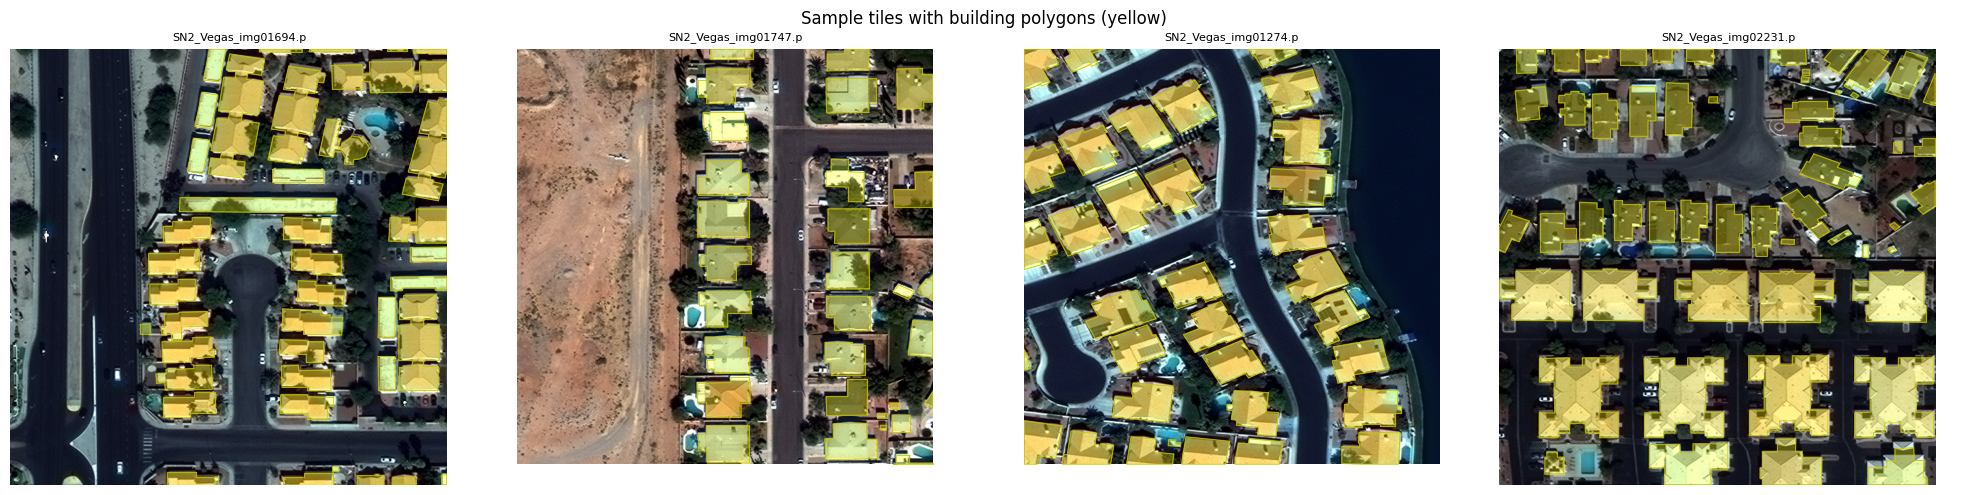

In [18]:
# ================================================================
# CREATE YOLO DATASET CONFIG
# ================================================================

yaml_content = f"""
path: {yolo_dir}
train: images/train
val: images/val

names:
  0: building
"""

yaml_path = os.path.join(yolo_dir, "dataset.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"Dataset config: {yaml_path}")
print(yaml_content)

# Verify with a visual check
sample_imgs = glob.glob(os.path.join(yolo_dir, "images", "train", "*.png"))[:4]
fig, axes = plt.subplots(1, min(4, len(sample_imgs)), figsize=(20, 5))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_imgs):
    img = np.array(Image.open(img_path))
    lbl_path = img_path.replace("/images/", "/labels/").replace(".png", ".txt")

    ax.imshow(img)
    if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue
                coords = [float(v) for v in parts[1:]]
                # Convert normalized to pixel
                h, w = img.shape[:2]
                xs = [coords[i] * w for i in range(0, len(coords), 2)]
                ys = [coords[i] * h for i in range(1, len(coords), 2)]
                ax.fill(xs, ys, alpha=0.3, color='yellow')
                ax.plot(xs + [xs[0]], ys + [ys[0]], 'y-', linewidth=0.5)

    ax.set_title(os.path.basename(img_path)[:20], fontsize=8)
    ax.axis("off")

plt.suptitle("Sample tiles with building polygons (yellow)", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ================================================================
# TRAIN YOLOv8l-SEG — Building Instance Segmentation
# ================================================================
# YOLOv8l-seg: ~46M params, excellent accuracy, fits T4 easily
# Training with FP16 automatically enabled by Ultralytics
# ================================================================

model = YOLO("yolov8l-seg.pt")  # Pretrained on COCO

print("=" * 60)
print("TRAINING: YOLOv8l-seg for Building Instance Segmentation")
print("=" * 60)

results = model.train(
    data=yaml_path,
    epochs=50,          # YOLO converges fast, early stopping built-in
    imgsz=640,
    batch=4,            # Fits T4 with FP16
    device=0,
    patience=10,        # Early stopping
    save=True,
    save_period=10,
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,           # Final LR = lr0 * lrf
    warmup_epochs=3,
    warmup_bias_lr=0.1,
    cos_lr=True,        # Cosine schedule
    # Augmentations
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=15.0,
    translate=0.1,
    scale=0.3,
    fliplr=0.5,
    flipud=0.5,         # Important for satellite imagery!
    mosaic=1.0,
    mixup=0.1,
    # Paths
    project=CKPT,
    name="yolo_building_seg",
    exist_ok=True,
    verbose=True,
)

print("\nTraining complete!")
print(f"Best model: {CKPT}/yolo_building_seg/weights/best.pt")


TRAINING: YOLOv8l-seg for Building Instance Segmentation
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/urban_project/work/yolo_dataset/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_building_seg, nb

In [ ]:
# ================================================================
# EVALUATE YOLO MODEL
# ================================================================

YOLO_BEST = os.path.join(CKPT, "yolo_building_seg", "weights", "best.pt")
yolo_model = YOLO(YOLO_BEST)

# Run validation
metrics = yolo_model.val(data=yaml_path, imgsz=640, batch=4, device=0)

print("\n" + "=" * 60)
print("BUILDING DETECTION METRICS")
print("=" * 60)
print(f"  Box mAP50:     {metrics.box.map50:.4f}")
print(f"  Box mAP50-95:  {metrics.box.map:.4f}")
print(f"  Mask mAP50:    {metrics.seg.map50:.4f}")
print(f"  Mask mAP50-95: {metrics.seg.map:.4f}")
print(f"  Precision:     {metrics.box.mp:.4f}")
print(f"  Recall:        {metrics.box.mr:.4f}")

# Show training curves
train_results = os.path.join(CKPT, "yolo_building_seg", "results.png")
if os.path.exists(train_results):
    img = Image.open(train_results)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLOv8 Training Curves")
    plt.show()


In [ ]:
# ================================================================
# VISUAL CHECK — YOLO Predictions on Validation Tiles
# ================================================================

val_imgs = glob.glob(os.path.join(yolo_dir, "images", "val", "*.png"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, img_path in zip(axes, val_imgs):
    results = yolo_model.predict(img_path, imgsz=640, conf=0.3, device=0, verbose=False)
    r = results[0]

    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    if r.masks is not None:
        for i, mask in enumerate(r.masks.data.cpu().numpy()):
            # Resize mask to image size
            mask_resized = cv2.resize(mask, (img.shape[1], img.shape[0]))
            color = plt.cm.tab20(i % 20)[:3]
            colored = np.zeros_like(img, dtype=np.float32)
            colored[:] = [c * 255 for c in color]
            overlay = img.astype(np.float32) * 0.6 + colored * 0.4 * mask_resized[:,:,None]
            img = np.where(mask_resized[:,:,None] > 0.5,
                          overlay.astype(np.uint8), img)

        # Draw bboxes
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].item()
            ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                        fill=False, edgecolor='lime', linewidth=1))
            ax.text(x1, y1-2, f"{conf:.2f}", color='lime', fontsize=7,
                   bbox=dict(fc='black', alpha=0.5, ec='none', pad=1))

    ax.imshow(img)
    n = len(r.boxes) if r.boxes is not None else 0
    ax.set_title(f"{n} buildings", fontsize=10)
    ax.axis("off")

plt.suptitle("YOLOv8-seg Predictions (green boxes + colored masks)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ================================================================
# KAGGLE SETUP + DEEPGLOBE DOWNLOAD (for Land Use)
# ================================================================

from google.colab import files as colab_files

print("Upload your kaggle.json:")
uploaded = colab_files.upload()
if uploaded:
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    fname = list(uploaded.keys())[0]
    with open(os.path.expanduser("~/.kaggle/kaggle.json"), "wb") as f:
        f.write(uploaded[fname])
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    print("Kaggle configured!")

DG_DIR = os.path.join(DATA, "deepglobe")
os.makedirs(DG_DIR, exist_ok=True)
!kaggle datasets download -d balraj98/deepglobe-land-cover-classification-dataset -p {DG_DIR} --unzip -q

dg_sat = sorted(glob.glob(os.path.join(DG_DIR, "**", "*_sat.*"), recursive=True))
dg_mask = sorted(glob.glob(os.path.join(DG_DIR, "**", "*_mask.*"), recursive=True))
print(f"DeepGlobe — Images: {len(dg_sat)}, Masks: {len(dg_mask)}")


In [ ]:
# ================================================================
# PROCESS DEEPGLOBE → 5-CLASS TILES
# ================================================================

N_LU = 5
LANDUSE_CLASSES = {0:'built_up', 1:'road', 2:'vegetation', 3:'open_land', 4:'water'}

DG_COLOR_MAP = {
    (0,255,255):0, (255,255,0):2, (255,0,255):3,
    (0,255,0):2, (0,0,255):4, (255,255,255):3, (0,0,0):3,
}

def dg_to_5class(mask_path):
    m = np.array(Image.open(mask_path).convert("RGB"))
    result = np.full(m.shape[:2], 3, dtype=np.uint8)
    for color, cls in DG_COLOR_MAP.items():
        result[np.all(m == np.array(color), axis=-1)] = cls
    return result

DG_TILE = 512
dg_tiles = os.path.join(WORK, "dg_tiles")
dg_img_dir = os.path.join(dg_tiles, "images")
dg_lu_dir = os.path.join(dg_tiles, "landuse")
os.makedirs(dg_img_dir, exist_ok=True)
os.makedirs(dg_lu_dir, exist_ok=True)

pairs = []
for sp in dg_sat:
    base = os.path.basename(sp).replace("_sat.jpg","").replace("_sat.png","")
    mc = [m for m in dg_mask if base in m]
    if mc: pairs.append((sp, mc[0]))

count = 0
for sp, mp in tqdm(pairs[:300], desc="Tiling DeepGlobe"):
    img = np.array(Image.open(sp).convert("RGB"))
    lu = dg_to_5class(mp)
    h, w = img.shape[:2]
    for y in range(0, h-DG_TILE+1, DG_TILE):
        for x in range(0, w-DG_TILE+1, DG_TILE):
            it = img[y:y+DG_TILE, x:x+DG_TILE]
            lt = lu[y:y+DG_TILE, x:x+DG_TILE]
            if len(np.unique(lt)) < 2: continue
            name = f"dg_{os.path.basename(sp).split('.')[0]}_{y}_{x}.png"
            Image.fromarray(it).save(os.path.join(dg_img_dir, name))
            Image.fromarray(lt).save(os.path.join(dg_lu_dir, name))
            count += 1

print(f"Saved {count} DeepGlobe tiles")


In [ ]:
# ================================================================
# TRAIN SEGFORMER-B2 — Land Use (5-class)
# ================================================================

class LandUseDataset(Dataset):
    def __init__(self, img_paths, mask_paths, processor, augment=False):
        self.imgs = img_paths
        self.masks = mask_paths
        self.proc = processor
        self.aug = augment

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img = np.array(Image.open(self.imgs[i]).convert("RGB"))
        mask = np.array(Image.open(self.masks[i]).convert("L"))
        mask = np.clip(mask, 0, N_LU - 1).astype(np.uint8)

        if self.aug:
            if random.random() > 0.5: img, mask = cv2.flip(img,1), cv2.flip(mask,1)
            if random.random() > 0.5: img, mask = cv2.flip(img,0), cv2.flip(mask,0)
            if random.random() > 0.5:
                k = random.choice([1,2,3])
                img, mask = np.rot90(img,k).copy(), np.rot90(mask,k).copy()
            if random.random() > 0.5:
                img = cv2.convertScaleAbs(img, alpha=random.uniform(0.8,1.2), beta=0)

        inp = self.proc(images=img, return_tensors="pt")
        return {"pixel_values": inp["pixel_values"].squeeze(0),
                "labels": torch.from_numpy(mask.copy()).long()}


# Dice + CE Loss
class DiceCELoss(nn.Module):
    def __init__(self, n=5, smooth=1.0):
        super().__init__()
        self.n = n; self.smooth = smooth; self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, target):
        if logits.shape[-2:] != target.shape[-2:]:
            logits = F.interpolate(logits, target.shape[-2:], mode='bilinear', align_corners=False)
        ce = self.ce(logits, target.long())
        pred = F.softmax(logits, dim=1)
        toh = F.one_hot(target.long(), self.n).permute(0,3,1,2).float()
        inter = (pred * toh).sum((0,2,3))
        union = pred.sum((0,2,3)) + toh.sum((0,2,3))
        dice = 1 - (2*inter + self.smooth) / (union + self.smooth)
        return 0.5 * ce + 0.5 * dice.mean()


# Prepare data
dg_imgs = sorted(glob.glob(os.path.join(dg_img_dir, "*.png")))
dg_lus = [os.path.join(dg_lu_dir, os.path.basename(p)) for p in dg_imgs]

random.seed(42)
idx = list(range(len(dg_imgs)))
random.shuffle(idx)
sp = int(0.85 * len(idx))
tr_idx, va_idx = idx[:sp], idx[sp:]

SEGFORMER_BASE = "nvidia/segformer-b2-finetuned-ade-512-512"
lu_proc = SegformerImageProcessor.from_pretrained(SEGFORMER_BASE)
lu_model = SegformerForSemanticSegmentation.from_pretrained(
    SEGFORMER_BASE, num_labels=N_LU, ignore_mismatched_sizes=True
).to(device)

train_ds = LandUseDataset([dg_imgs[i] for i in tr_idx], [dg_lus[i] for i in tr_idx],
                           lu_proc, augment=True)
val_ds = LandUseDataset([dg_imgs[i] for i in va_idx], [dg_lus[i] for i in va_idx],
                         lu_proc, augment=False)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

# Training
criterion = DiceCELoss(n=N_LU)
optimizer = torch.optim.AdamW(lu_model.parameters(), lr=2e-4, weight_decay=0.01)
total_steps = 20 * len(train_loader) // 4
scheduler = get_cosine_schedule_with_warmup(optimizer, min(500, total_steps//5), total_steps)
scaler = GradScaler()

LU_EPOCHS = 20
best_iou = 0
patience = 0

print("=" * 60)
print("TRAINING: SegFormer-B2 Land Use (5-class)")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Epochs: {LU_EPOCHS}")
print("=" * 60)

for epoch in range(LU_EPOCHS):
    # Train
    lu_model.train()
    total_loss = 0
    optimizer.zero_grad()
    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)):
        pv = batch["pixel_values"].to(device)
        lb = batch["labels"].to(device)
        with autocast():
            logits = lu_model(pixel_values=pv).logits
            loss = criterion(logits, lb) / 4
        scaler.scale(loss).backward()
        if (step+1) % 4 == 0 or (step+1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(lu_model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
        total_loss += loss.item() * 4

    # Validate
    lu_model.eval()
    val_loss = 0; all_ious = []
    with torch.no_grad():
        for batch in val_loader:
            pv = batch["pixel_values"].to(device)
            lb = batch["labels"].to(device)
            with autocast():
                logits = lu_model(pixel_values=pv).logits
                val_loss += criterion(logits, lb).item()
            pred = F.interpolate(logits, lb.shape[-2:], mode='bilinear',
                                align_corners=False).argmax(1).cpu().numpy()
            gt = lb.cpu().numpy()
            for b in range(pred.shape[0]):
                ious = []
                for c in range(N_LU):
                    inter = ((pred[b]==c) & (gt[b]==c)).sum()
                    union = ((pred[b]==c) | (gt[b]==c)).sum()
                    ious.append(inter/(union+1e-8))
                all_ious.append(ious)

    miou = np.nanmean(all_ious)
    print(f"  Epoch {epoch+1}/{LU_EPOCHS} — loss: {total_loss/len(train_loader):.4f} | "
          f"val_loss: {val_loss/len(val_loader):.4f} | mIoU: {miou:.4f}")

    if miou > best_iou:
        best_iou = miou
        patience = 0
        LU_CKPT = os.path.join(CKPT, "landuse_segformer_b2")
        lu_model.save_pretrained(LU_CKPT)
        lu_proc.save_pretrained(LU_CKPT)
        print(f"    ★ Best mIoU={best_iou:.4f} saved!")
    else:
        patience += 1
        if patience >= 6:
            print(f"    Early stopping at epoch {epoch+1}")
            break
    torch.cuda.empty_cache()

print(f"\nBest Land Use mIoU: {best_iou:.4f}")


In [ ]:
# ================================================================
# FULL INFERENCE PIPELINE
# ================================================================
# YOLOv8-seg → buildings (bbox + mask + ID + confidence)
# SegFormer-B2 → land use (5-class semantic)
# Combined → final analysis
# ================================================================

from dataclasses import dataclass

@dataclass
class BuildingResult:
    building_id: str
    bbox: List[int]       # [x1, y1, x2, y2]
    mask: np.ndarray      # binary mask
    confidence: float
    area_px: int
    area_m2: float
    centroid: Tuple[int, int]

LANDUSE_COLORS = {
    0: (220,60,60), 1: (150,150,255), 2: (60,220,60),
    3: (230,200,70), 4: (60,140,255),
}
LANDUSE_LABELS = {0:"Built-up", 1:"Road", 2:"Vegetation", 3:"Open Land", 4:"Water"}

# Load models
YOLO_BEST = os.path.join(CKPT, "yolo_building_seg", "weights", "best.pt")
yolo_model = YOLO(YOLO_BEST)

LU_CKPT = os.path.join(CKPT, "landuse_segformer_b2")
lu_proc = SegformerImageProcessor.from_pretrained(LU_CKPT)
lu_mod = SegformerForSemanticSegmentation.from_pretrained(LU_CKPT).to(device).eval()

MPP = 0.3  # meters per pixel (SpaceNet Vegas default)


def predict_buildings(image_rgb, conf=0.3):
    results = yolo_model.predict(image_rgb, imgsz=640, conf=conf,
                                  device=0, verbose=False)
    r = results[0]
    buildings = []
    h, w = image_rgb.shape[:2]

    if r.masks is None or r.boxes is None:
        return buildings

    for i in range(len(r.boxes)):
        box = r.boxes[i]
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        conf_val = box.conf[0].item()

        mask = r.masks.data[i].cpu().numpy()
        mask = cv2.resize(mask, (w, h)) > 0.5

        area_px = int(mask.sum())
        area_m2 = round(area_px * MPP**2, 2)

        ys, xs = np.where(mask)
        if len(xs) == 0:
            continue
        cx, cy = int(xs.mean()), int(ys.mean())

        buildings.append(BuildingResult(
            building_id=f"BLD-{i+1:04d}",
            bbox=[int(x1), int(y1), int(x2), int(y2)],
            mask=mask.astype(np.uint8),
            confidence=round(conf_val, 4),
            area_px=area_px,
            area_m2=area_m2,
            centroid=(cx, cy),
        ))

    return buildings


@torch.no_grad()
def predict_landuse(image_rgb):
    h, w = image_rgb.shape[:2]
    inp = lu_proc(images=image_rgb, return_tensors="pt").to(device)
    with autocast():
        logits = lu_mod(**inp).logits
    up = F.interpolate(logits, (h,w), mode='bilinear', align_corners=False)
    return up.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)


def combine_results(buildings, lu_pred):
    result = lu_pred.copy()
    for b in buildings:
        result[b.mask > 0] = 0
    return result


def landuse_pct(mask):
    total = mask.size
    return {LANDUSE_CLASSES[i]: round(float((mask==i).sum()/total*100), 2)
            for i in range(N_LU)}


def neighborhood_analysis(lu_mask, buildings, rows=3, cols=3):
    h, w = lu_mask.shape
    report = []
    for r in range(rows):
        for c in range(cols):
            y0, y1 = int(r*h/rows), int((r+1)*h/rows)
            x0, x1 = int(c*w/cols), int((c+1)*w/cols)
            lu = lu_mask[y0:y1, x0:x1]
            total = lu.size
            pct = {LANDUSE_CLASSES[i]: round(float((lu==i).sum()/total*100),1)
                   for i in range(N_LU)}

            n_bld = 0
            bld_ids = []
            for b in buildings:
                cx, cy = b.centroid
                if x0 <= cx < x1 and y0 <= cy < y1:
                    n_bld += 1
                    bld_ids.append(b.building_id)

            report.append({
                "cell": f"R{r}C{c}", "bbox": [x0,y0,x1,y1],
                "buildings": n_bld, "building_ids": bld_ids,
                "pct": pct
            })
    return report


print("Full pipeline ready!")
print("  - YOLOv8-seg: Building detection + instance masks")
print("  - SegFormer-B2: Land use classification")


In [ ]:
# ================================================================
# VISUALIZATION
# ================================================================

def visualize_full(img, buildings, lu_final, neighborhoods=None, save_path=None):
    h, w = img.shape[:2]
    n_bld = len(buildings)
    pct = landuse_pct(lu_final)

    fig = plt.figure(figsize=(24, 16))
    fig.patch.set_facecolor('#0d1117')

    title = (f'UrbanInsight (YOLO+SegFormer)  |  Buildings: {n_bld}  |  '
             + '  '.join(f'{LANDUSE_LABELS[i]}: {pct[LANDUSE_CLASSES[i]]:.1f}%'
                        for i in [0,2,3]))
    fig.suptitle(title, fontsize=14, fontweight='bold', color='white', y=0.99)

    gs = fig.add_gridspec(2, 3, hspace=0.25, wspace=0.12,
                          left=0.02, right=0.98, top=0.94, bottom=0.02)
    axes = [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(3)]

    # [0] Original
    axes[0].imshow(img)
    axes[0].set_title('Original', color='white', fontsize=13, pad=8)

    # [1] Building detection (YOLO bboxes + masks)
    bld_vis = img.copy()
    for b in buildings:
        color = np.random.randint(100, 255, 3)
        bld_vis[b.mask > 0] = (bld_vis[b.mask > 0] * 0.5 + color * 0.5).astype(np.uint8)
        x1,y1,x2,y2 = b.bbox
        axes[1].add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1,
                          fill=False, edgecolor='lime', linewidth=1))
    axes[1].imshow(bld_vis)
    axes[1].set_title(f'Buildings — {n_bld} detected (YOLO)', color='white', fontsize=13, pad=8)

    # [2] Land use overlay
    lu_vis = img.copy()
    for cls_id, col in LANDUSE_COLORS.items():
        idx = (lu_final == cls_id)
        if idx.any():
            lu_vis[idx] = (lu_vis[idx]*0.55 + np.array(col)*0.45).astype(np.uint8)
    axes[2].imshow(lu_vis)
    legend = [mpatches.Patch(color=np.array(LANDUSE_COLORS[i])/255,
              label=f'{LANDUSE_LABELS[i]} {pct[LANDUSE_CLASSES[i]]:.1f}%')
              for i in range(N_LU)]
    axes[2].legend(handles=legend, loc='upper right', fontsize=8,
                   framealpha=0.8, facecolor='#111', labelcolor='white')
    axes[2].set_title('Land Use (5-class)', color='white', fontsize=13, pad=8)

    # [3] Land use map
    lu_rgb = np.zeros((h,w,3), dtype=np.uint8)
    for cls_id, col in LANDUSE_COLORS.items():
        lu_rgb[lu_final == cls_id] = col
    axes[3].imshow(lu_rgb)
    axes[3].set_title('Land Use Map', color='white', fontsize=13, pad=8)

    # [4] Building IDs
    axes[4].imshow(img)
    for b in buildings[:200]:
        x1,y1,x2,y2 = b.bbox
        axes[4].add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1,
                          fill=False, edgecolor='yellow', linewidth=1))
        cx, cy = b.centroid
        axes[4].text(cx, cy, b.building_id[-4:], color='white', fontsize=5,
                    ha='center', va='center',
                    bbox=dict(fc='black', alpha=0.6, ec='none', pad=0.5))
    axes[4].set_title(f'Building IDs — {n_bld}', color='white', fontsize=13, pad=8)

    # [5] Stats
    ax5 = axes[5]
    ax5.set_facecolor('#161b22'); ax5.axis('off')
    ax5.set_xlim(0,1); ax5.set_ylim(0,1)
    def T(x,y,s,sz=11,col='white',fw='normal',ha='center'):
        ax5.text(x,y,s,transform=ax5.transAxes,fontsize=sz,color=col,ha=ha,va='center',fontweight=fw)
    T(0.5,0.95,'Scene Statistics',14,'white','bold')
    info = [
        ('Buildings', str(n_bld), '#FFB347'),
        ('Image', f'{w}x{h}', '#87CEEB'),
        ('Built-up', f"{pct['built_up']:.1f}%", '#DC3C3C'),
        ('Road', f"{pct['road']:.1f}%", '#9696FF'),
        ('Vegetation', f"{pct['vegetation']:.1f}%", '#3CDC3C'),
        ('Open Land', f"{pct['open_land']:.1f}%", '#E6C846'),
        ('Water', f"{pct['water']:.1f}%", '#3C8CFF'),
    ]
    if buildings:
        avg_area = np.mean([b.area_m2 for b in buildings])
        info.append(('Avg area', f"{avg_area:.0f} m²", '#FFB347'))
    for i,(k,v,col) in enumerate(info):
        yp = 0.82 - i*0.08
        T(0.08,yp,k,10,'#AAA',ha='left')
        T(0.92,yp,v,10,col,ha='right')

    for ax in axes[:5]:
        ax.set_facecolor('#0d1117')
        for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
        ax.tick_params(colors='#555', labelsize=6)

    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight', facecolor='#0d1117')
        print(f'Saved: {save_path}')
    plt.show()


print("Visualization ready!")


In [ ]:
# ================================================================
# UPLOAD & ANALYZE YOUR IMAGE
# ================================================================

from google.colab import files as colab_files
import io

print("Upload your aerial/satellite image (JPG, PNG)")
uploaded = colab_files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    img = np.array(Image.open(io.BytesIO(uploaded[fname])).convert("RGB"))
    print(f"\nUploaded: {fname} ({img.shape[1]}x{img.shape[0]})")

    # Step 1: Detect buildings
    print("\n[1/3] Detecting buildings (YOLOv8-seg)...")
    buildings = predict_buildings(img, conf=0.3)
    print(f"  Found: {len(buildings)} buildings")
    for b in buildings[:5]:
        print(f"    {b.building_id}: {b.area_m2:.1f} m² (conf={b.confidence:.3f})")

    # Step 2: Land use
    print("\n[2/3] Classifying land use (SegFormer-B2)...")
    lu_pred = predict_landuse(img)
    lu_final = combine_results(buildings, lu_pred)
    pct = landuse_pct(lu_final)
    print(f"  {pct}")

    # Step 3: Neighborhood analysis
    print("\n[3/3] Neighborhood analysis...")
    nb_report = neighborhood_analysis(lu_final, buildings, 3, 3)
    print("=" * 80)
    print("NEIGHBORHOOD ANALYSIS")
    print("=" * 80)
    for row in nb_report:
        p = row["pct"]
        print(f"[{row['cell']}] bld={row['buildings']:>3} | "
              f"built={p['built_up']:5.1f}% veg={p['vegetation']:5.1f}% "
              f"open={p['open_land']:5.1f}%")

    # Visualize
    save_path = os.path.join(OUT, "analysis.png")
    visualize_full(img, buildings, lu_final, nb_report, save_path)

    # Save results
    bld_data = [{"id": b.building_id, "bbox": b.bbox,
                 "area_px": b.area_px, "area_m2": b.area_m2,
                 "confidence": b.confidence, "centroid": list(b.centroid)}
                for b in buildings]
    with open(os.path.join(OUT, "buildings.json"), "w") as f:
        json.dump(bld_data, f, indent=2)
    with open(os.path.join(OUT, "landuse.json"), "w") as f:
        json.dump(pct, f, indent=2)
    with open(os.path.join(OUT, "neighborhoods.json"), "w") as f:
        json.dump(nb_report, f, indent=2)

    # Save masks
    np.save(os.path.join(OUT, "landuse_mask.npy"), lu_final)
    for b in buildings:
        np.save(os.path.join(OUT, f"{b.building_id}_mask.npy"), b.mask)

    print(f"\nAll results saved to {OUT}")
    print(f"Buildings: {len(buildings)} | Avg area: {np.mean([b.area_m2 for b in buildings]):.0f} m²")
else:
    print("No file uploaded.")


In [ ]:
# ================================================================
# DOWNLOAD RESULTS
# ================================================================
import zipfile
from google.colab import files as colab_files

zip_path = os.path.join(BASE, "urban_results.zip")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in glob.glob(os.path.join(OUT, "*.json")) + glob.glob(os.path.join(OUT, "*.png")):
        zf.write(f, os.path.basename(f))

print(f"Results zip: {zip_path}")
colab_files.download(zip_path)
